주어진 파일 “gaia_purewb_valueadded_base.csv”을 읽어 드린 후에 다음 작업을
수행하는 코드를 작성하라. 총 쌍성 수는 4276.

각 쌍성에 대한 s값과 vp값을 읽어 드린 후 다음 작업을 수행하는 코드를 짜라.

s값과 vp값에 밑을 10으로 하는 log를 취한 후에 이들을 scatter plot을 써서 나타내라. s값
의 단위는 au를 사용하라. 즉, 읽어드린 값에 1000을 곱하라. vp값의 단위는 m/s를 사용하
라. 즉, 읽어드린 값에 1000을 곱하라.

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# pandas 이용해서 csv 형식인 “gaia_purewb_3D_valueadded_stat.csv” 파일 읽기. / df; data frame(데이터 프레임)
df = pd.read_csv("gaia_purewb_valueadded_base.csv")

# 필요한 2개의 열들만 추출.
cols = ['s[kau]', 'vp[km/s]']
df = df[cols]

# 단위 변환 / kau → au, km/s → m/s
df['s'] = df['s[kau]'] * 1000  # kau → au
df['vp'] = df['vp[km/s]'] * 1000  # km/s → m/s

(1) s값의 범위를 log구간에서 균등하게 6등분한 후에 각 구간에서 log10{s} 와 log10{v}의 중간
값을 구하고, 이 중간값들을 위의 scatter plot위에 굵은 점들을 써서 나타내라.

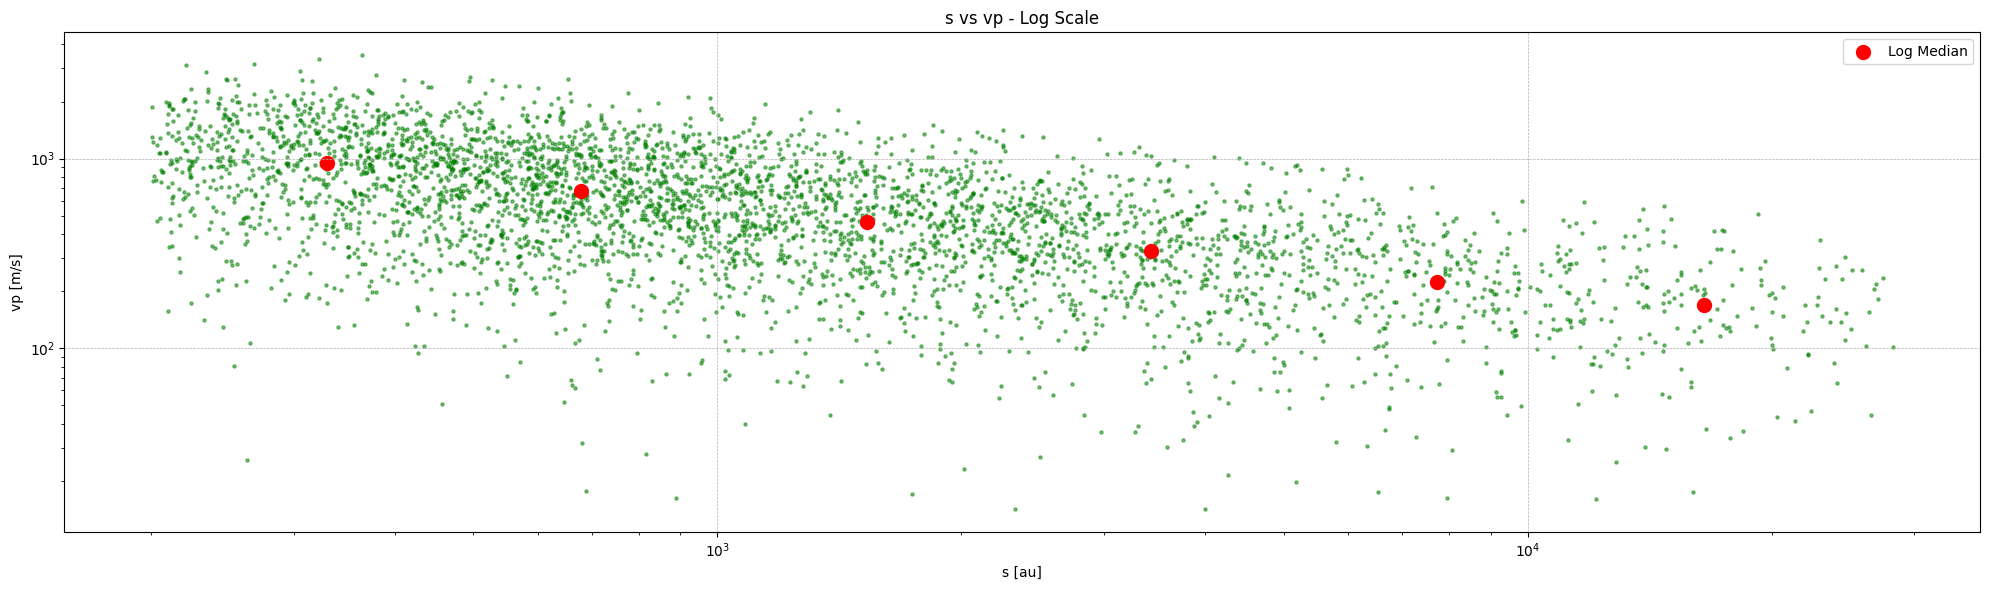

In [123]:
# 로그 변환
df['log_s'] = np.log10(df['s'])
df['log_vp'] = np.log10(df['vp'])

# log_s 범위를 6등분
bins = np.linspace(df['log_s'].min(), df['log_s'].max(), 7)
df['s_bin'] = pd.cut(df['log_s'], bins, labels=False)

# 그냥, s & vp가 아닌, 로그 변환값의 중간값으로 계산
log_medians = df.groupby('s_bin')[['log_s', 'log_vp']].median()

# 패널 생성
fig, axes = plt.subplots(figsize=(20, 6))
axes.scatter(df['s'], df['vp'], s=5, alpha=0.5, c='green')
axes.scatter(10**log_medians['log_s'],10**log_medians['log_vp'],color='red', s=100, label='Log Median')

# 축 설정
axes.set_xscale('log')
axes.set_yscale('log')
axes.set_title('s vs vp - Log Scale')
axes.set_xlabel('s [au]')
axes.set_ylabel('vp [m/s]')
axes.legend()
axes.grid(True, which='major', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

(2) 이 점들을 붉은색 선으로 연결하고, 이 선을 첫 3개 구간 점들만으로 구한 직선을 무한대로 연장하는 파란색 직선을 그리라.

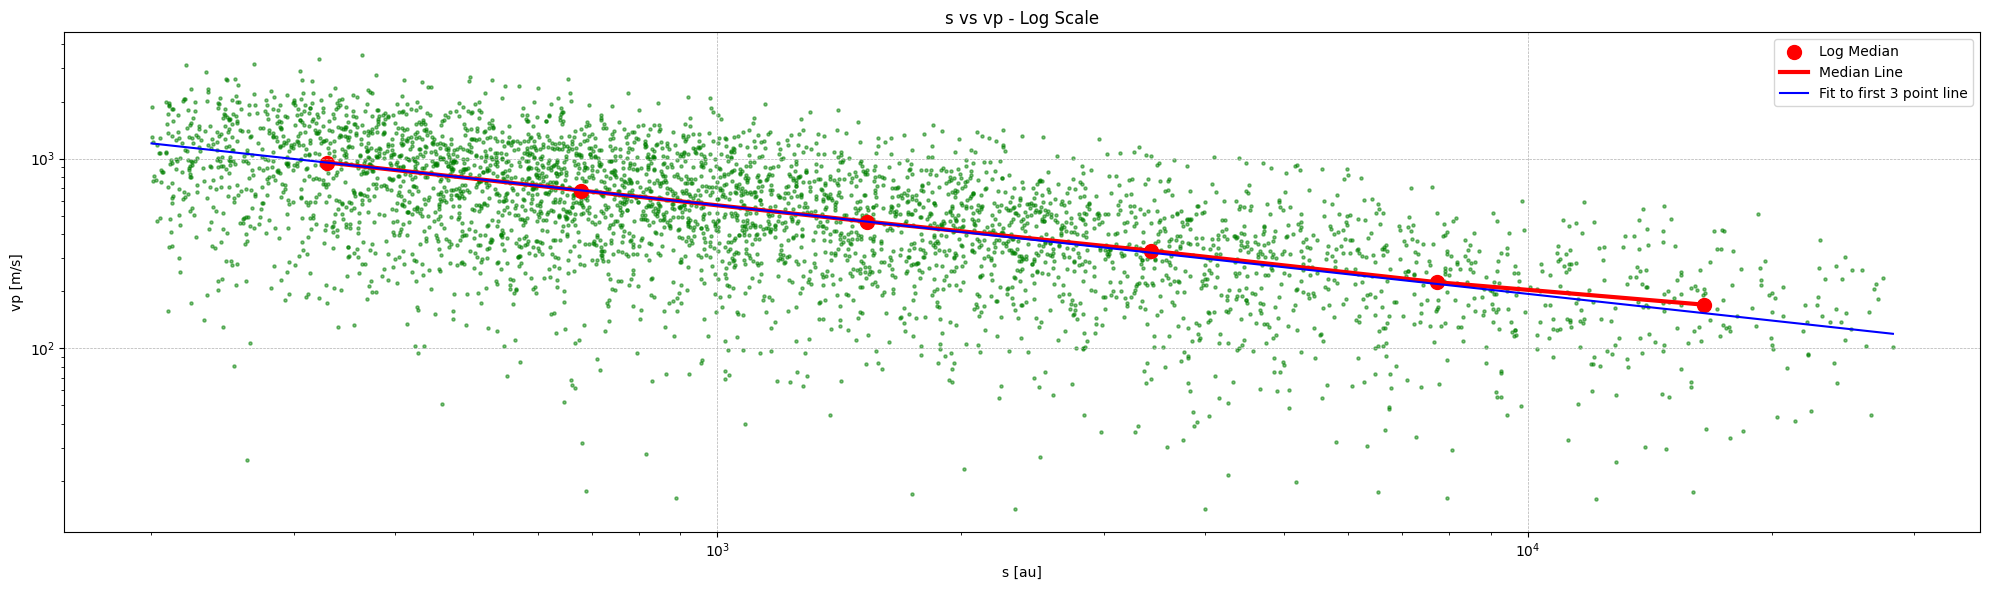

In [124]:
from scipy import stats

fig, axes = plt.subplots(figsize=(20, 6))

# 원래 값으로 산점도 및 중앙값 표시
axes.scatter(df['s'], df['vp'], s=5, alpha=0.5, c='green')
axes.scatter(10**log_medians['log_s'], 10**log_medians['log_vp'], color='red', s=100, label='Log Median')

# 중앙값을 잇는 선
axes.plot(10**log_medians['log_s'], 10**log_medians['log_vp'], color='red', linewidth=3, label='Median Line')

#첫 점 세 개를 이용해서 직선 긋기
first_3_log_s = log_medians['log_s'].iloc[:3]
first_3_log_vp = log_medians['log_vp'].iloc[:3]

# 로그 공간에서 선형 회귀
slope_vp, intercept_vp, r_value_vp, _, _ = stats.linregress(first_3_log_s, first_3_log_vp)

s_fit = np.logspace(np.log10(df['s'].min()), np.log10(df['s'].max()), 100)
vp_fit = 10**(slope_vp * np.log10(s_fit) + intercept_vp)
axes.plot(s_fit, vp_fit, color='blue', label='Fit to first 3 point line')

# 로그 스케일 설정
axes.set_xscale('log')
axes.set_yscale('log')
axes.set_title('s vs vp - Log Scale')
axes.set_xlabel('s [au]')
axes.set_ylabel('vp [m/s]')
axes.legend()
axes.grid(True, which='major', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

(3) 파란색 선의 기울기가 얼마인가? 그 의미는 무엇일까?

In [125]:
print(slope_vp)

-0.4670513388352032


**파란색 직선 기울기의 의미**

우선 이곳에서 변수 s와 vp가 무엇을 의미하는지부터 이야기하겠다.

우선 s는 쌍성계에서 두 별 사이의 거리를 나타내며, 원래 단위는 kAU였으나, 이곳에서는 AU(Astronomical Unit)로 변환했다.

vp는 쌍성계에서의 속도 측정값이고, 원래 단위는 km/s였으나, 이곳에서는 m/s로 변환했다. 또한, 이 vp값은 케플러 역학에 따른 쌍성계의 궤도 속도의 투영 값이라는 물리적 의미를 지니고 있다. 그리고 분석한 데이터에서의 의미는, 두 별이 공통 질량 중심 주위를 회전할 때의 상대적 속도를 나타낸다.


현재 파란색 직선은, 별 사이의 거리 s가 x축, 투영 궤도 속도 vp로 y축 이루어진 좌표에 위치한다. 나의 분석 결과로, 이 직선의 기울기는 -0.4670513388352032로 계산된다. 이는 약 -0.5인데, 이 값은 케플러의 제3법칙과 관련이 있다. 케플러의 제3법칙에 따르면, 궤도 속도의 제곱(v²)이 총 질량(M)에 비례하고 별 사이 거리(r)에 반비례하는 관계(v² ∝ M/r)가 성립한다. 그리고 이를 로그 형태로 변환해 표현하면, log(v) = -0.5log(r) + 0.5long(M) + (상수) 형태로 표현된다.

 이때 기울기가 약 -0.5라는 것은, 내가 분석한 쌍성계가 케플러 역학을 따른다는 증거가 된다. 그리고 현재 분석 결과가, 별 사이의 거리(s)가 증가할수록, 투영 궤도 속도(vp)는 거리의 (-0.5)승에 비례해서 감소한다. v ∝ r^(-0.5) - '승'에 비례해 감소하는데, 코드 결과로 나타낸 그래프에서는 직선으로 나타난다. 이는 로그 스케일로 변환했기 떄문이다. - 이는 중력에 의한 쌍성계의 기본적 역학적 특징을 보여준다고 할 수 있다.


.

(4) 붉은색 선이 파란색 선과 일치하는 것으로 보이는가? 여부를 말하고 그 의미를 논하라.


붉은색 선은 모든 여섯 구간의 log{s}와 log{vp} 중간값들을 연결한 선이고, 파란색 선은 첫 세 구간의 중간값으로 계산한 회귀선을 전체 범위로 확장한 것이다.

그래프를 보면, 붉은색 선과 파란색 선은 작은 s값(가까운 거리)에서는 잘 일치하지만, 큰 s값(먼 거리)에서는 점차 어긋나는 모습을 볼 수 있다. 이는 다음과 같이 해석할 수 있다.

 첫째로, 가까운 거리에서 보이는 두 직선의 일치는 가까운 쌍성계는 단순한 케플러 역학으로 잘 설명된다는 뜻이다.
 둘째로, 먼 거리에서 보이는 불일치는 단순한 케플러 역학으로 설명하기 어렵다는 것을 뜻하고, 이는 외부 중력의 영향, 먼 거리에서의 관측 오차 등의 요인으로 작용할 수 있다.

 결과적으로, 이러한 붉은색 선과 파란색 선의 차이는, 단순한 케플러 모델만으로는 모든 거리 범위에서의 쌍성 역학을 완전히 설명할 수 없음을 보여준다.

 ruwe1 < 1.3과 ruwe2 < 1.3을 만족 시키는 쌍성들에 대해서만 위 (1) ~ (4)를 반복하라.
다른 패널을 사용하라.

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# pandas 이용해서 csv 형식인 “gaia_purewb_3D_valueadded_stat.csv” 파일 읽기. / df; data frame(데이터 프레임)
df = pd.read_csv("gaia_purewb_valueadded_base.csv")

# 필요한 2개의 열들만 추출.
cols = ['s[kau]', 'vp[km/s]', 'ruwe1', 'ruwe2']
df = df[cols]

# 단위 변환 / kau → au, km/s → m/s
df['s'] = df['s[kau]'] * 1000  # kau → au
df['vp'] = df['vp[km/s]'] * 1000  # km/s → m/s

# 조건을 만족하는 데이터만 선택
df_cho_1 = df[(df['ruwe1'] < 1.3) & (df['ruwe2'] < 1.3)]

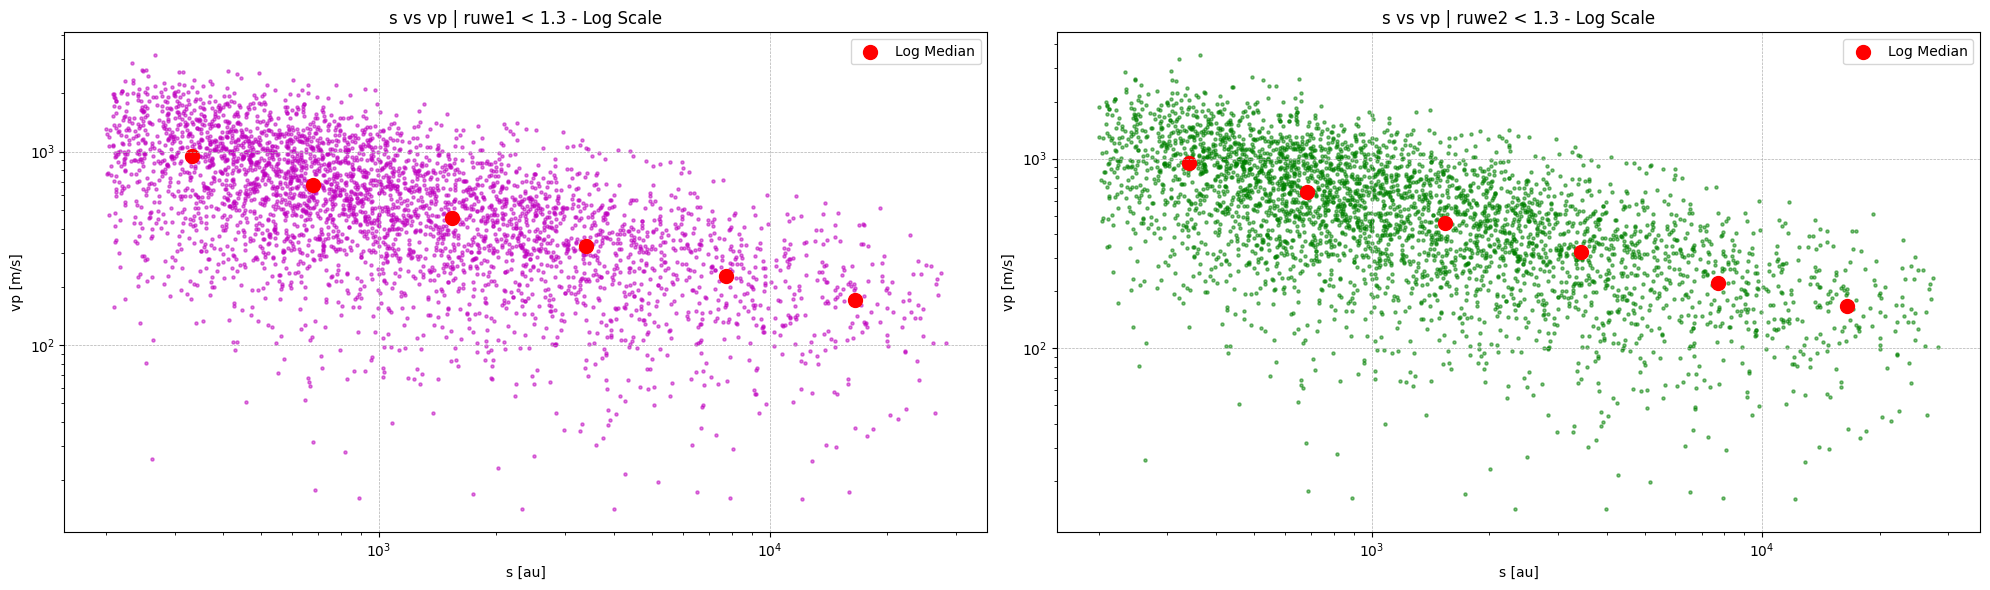

In [127]:
# 로그 변환
df['log_s'] = np.log10(df['s'])
df['log_vp'] = np.log10(df['vp'])

# log_s 범위를 6등분
bins = np.linspace(df['log_s'].min(), df['log_s'].max(), 7)

#rowe1
df_r1 = df[df['ruwe1'] < 1.3].copy()
df_r1['s_bin'] = pd.cut(df_r1['log_s'], bins, labels=False)
log_medians_r1 = df_r1.groupby('s_bin')[['log_s', 'log_vp']].median()

#rowe2
df_r2 = df[df['ruwe2'] < 1.3].copy()
df_r2['s_bin'] = pd.cut(df_r2['log_s'], bins, labels=False)
log_medians_r2 = df_r2.groupby('s_bin')[['log_s', 'log_vp']].median()

# 패널 생성
fig, axes = plt.subplots(1,2,figsize=(20, 6))
axes[0].scatter(df_r1['s'], df_r1['vp'], s=5, alpha=0.5, c='m')
axes[0].scatter(10**log_medians_r1['log_s'],10**log_medians_r1['log_vp'],color='red', s=100, label='Log Median')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('s vs vp | ruwe1 < 1.3 - Log Scale')
axes[0].set_xlabel('s [au]')
axes[0].set_ylabel('vp [m/s]')
axes[0].legend()
axes[0].grid(True, which='major', linestyle='--', linewidth=0.5)


axes[1].scatter(df_r2['s'], df_r2['vp'], s=5, alpha=0.5, c='green')
axes[1].scatter(10**log_medians_r2['log_s'],10**log_medians_r2['log_vp'],color='red', s=100, label='Log Median')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('s vs vp | ruwe2 < 1.3 - Log Scale')
axes[1].set_xlabel('s [au]')
axes[1].set_ylabel('vp [m/s]')
axes[1].legend()
axes[1].grid(True, which='major', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

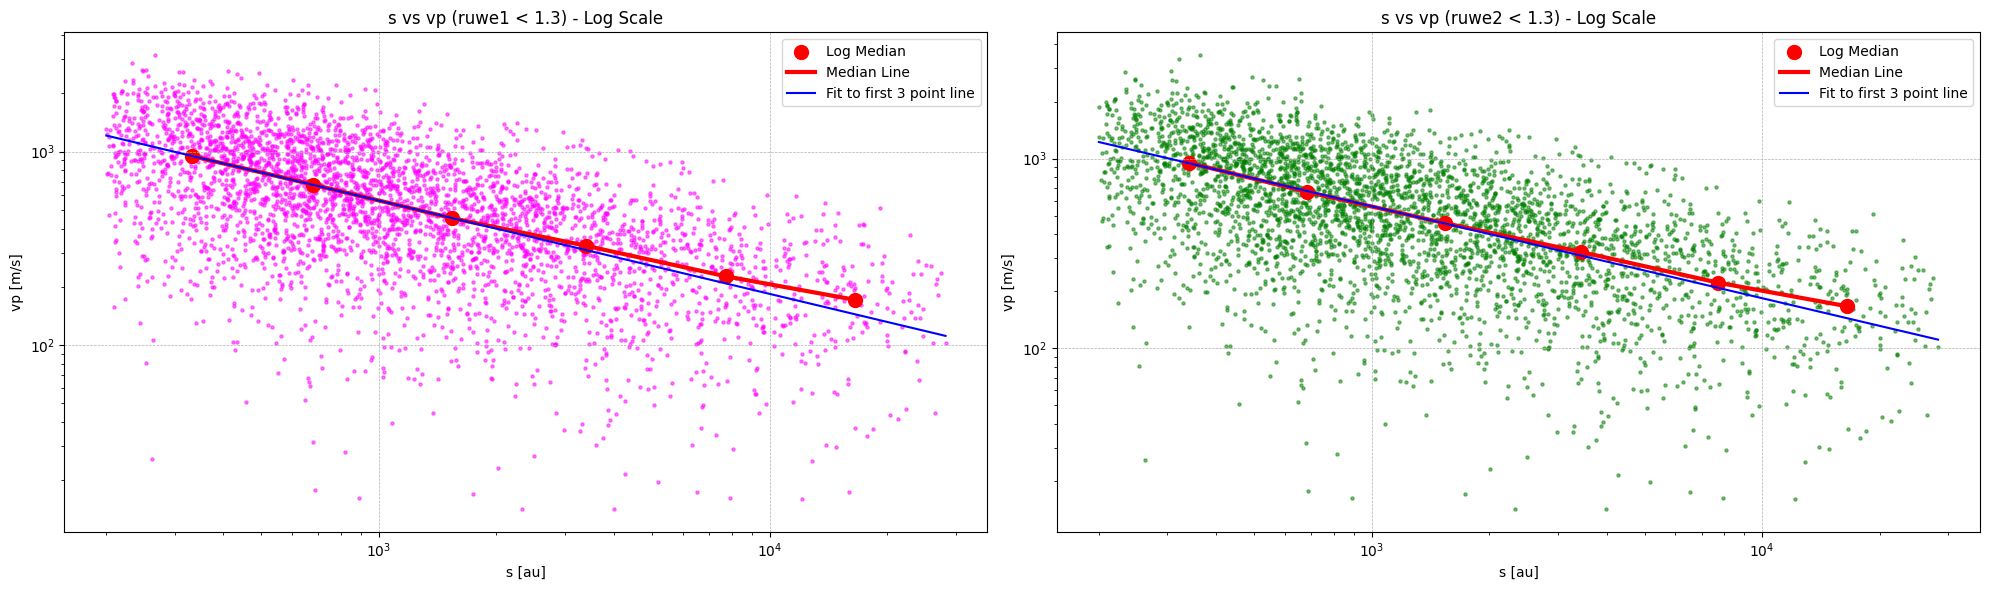

In [129]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# 첫 번째 패널 (ruwe1 < 1.3)
axes[0].scatter(df_r1['s'], df_r1['vp'], s=5, alpha=0.5, c='magenta')
axes[0].scatter(10**log_medians_r1['log_s'], 10**log_medians_r1['log_vp'], color='red', s=100, label='Log Median')

# 중앙값을 잇는 붉은색 선
axes[0].plot(10**log_medians_r1['log_s'], 10**log_medians_r1['log_vp'], color='red', linewidth=3, label='Median Line')

# 첫 3개 구간 중앙값에 대한 회귀 분석
first_3_log_s_r1 = log_medians_r1['log_s'].iloc[:3]
first_3_log_vp_r1 = log_medians_r1['log_vp'].iloc[:3]
slope_vp_r1, intercept_vp_r1, r_value_vp_r1, _, _ = stats.linregress(first_3_log_s_r1, first_3_log_vp_r1)

# 회귀 직선용 s 값 생성 및 파란색 직선 그리기
s_fit_r1 = np.logspace(np.log10(df_r1['s'].min()), np.log10(df_r1['s'].max()), 100)
vp_fit_r1 = 10**(slope_vp_r1 * np.log10(s_fit_r1) + intercept_vp_r1)
axes[0].plot(s_fit_r1, vp_fit_r1, color='blue', label='Fit to first 3 point line')

# ruwe1 패널 설정
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('s vs vp (ruwe1 < 1.3) - Log Scale')
axes[0].set_xlabel('s [au]')
axes[0].set_ylabel('vp [m/s]')
axes[0].legend()
axes[0].grid(True, which='major', linestyle='--', linewidth=0.5)

# 두 번째 패널 (ruwe2 < 1.3)
axes[1].scatter(df_r2['s'], df_r2['vp'], s=5, alpha=0.5, c='green')
axes[1].scatter(10**log_medians_r2['log_s'], 10**log_medians_r2['log_vp'], color='red', s=100, label='Log Median')

# 중앙값을 잇는 붉은색 선
axes[1].plot(10**log_medians_r2['log_s'], 10**log_medians_r2['log_vp'], color='red', linewidth=3, label='Median Line')

# 첫 3개 구간 중앙값에 대한 회귀 분석
first_3_log_s_r2 = log_medians_r2['log_s'].iloc[:3]
first_3_log_vp_r2 = log_medians_r2['log_vp'].iloc[:3]
slope_vp_r2, intercept_vp_r2, r_value_vp_r2, _, _ = stats.linregress(first_3_log_s_r2, first_3_log_vp_r2)
stats.linregress(first_3_log_s_r2, first_3_log_vp_r2)

# 회귀 직선용 s 값 생성 및 파란색 직선 그리기
s_fit_r2 = np.logspace(np.log10(df_r2['s'].min()), np.log10(df_r2['s'].max()), 100)
vp_fit_r2 = 10**(slope_vp_r2 * np.log10(s_fit_r2) + intercept_vp_r2)
axes[1].plot(s_fit_r2, vp_fit_r2, color='blue', label='Fit to first 3 point line')

# ruwe2 패널 설정
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('s vs vp (ruwe2 < 1.3) - Log Scale')
axes[1].set_xlabel('s [au]')
axes[1].set_ylabel('vp [m/s]')
axes[1].legend()
axes[1].grid(True, which='major', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [134]:
print(slope_vp_r1)
print(slope_vp_r2)

-0.4819318061489864
-0.484679207690691


(6) 이제는 M1과 M2를 읽어드린 후에 총 질량 즉 Mtot=M1+M2의 값을 log10 𝑠에 대한
scatter plot으로 나타내라. 위의 6개 구간에서 Mtot의 중간 값들을 구한 후에 scatter plot위에 굵은 점들을 써서 나타내라. 또한, 이 중간 값들의 중간 값을 지나는 x축에 평행한 선을
dashed 스타일로 그리라.

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# pandas 이용해서 csv 형식인 “gaia_purewb_3D_valueadded_stat.csv” 파일 읽기. / df; data frame(데이터 프레임)
df = pd.read_csv("gaia_purewb_valueadded_base.csv")

# 필요한 2개의 열들만 추출.
cols = ['s[kau]', 'M1[Msun]', 'M2[Msun]']
df = df[cols]

df['s'] = df['s[kau]'] * 1000  # kau → au

df['Mtot'] = df['M1[Msun]'] + df['M2[Msun]']

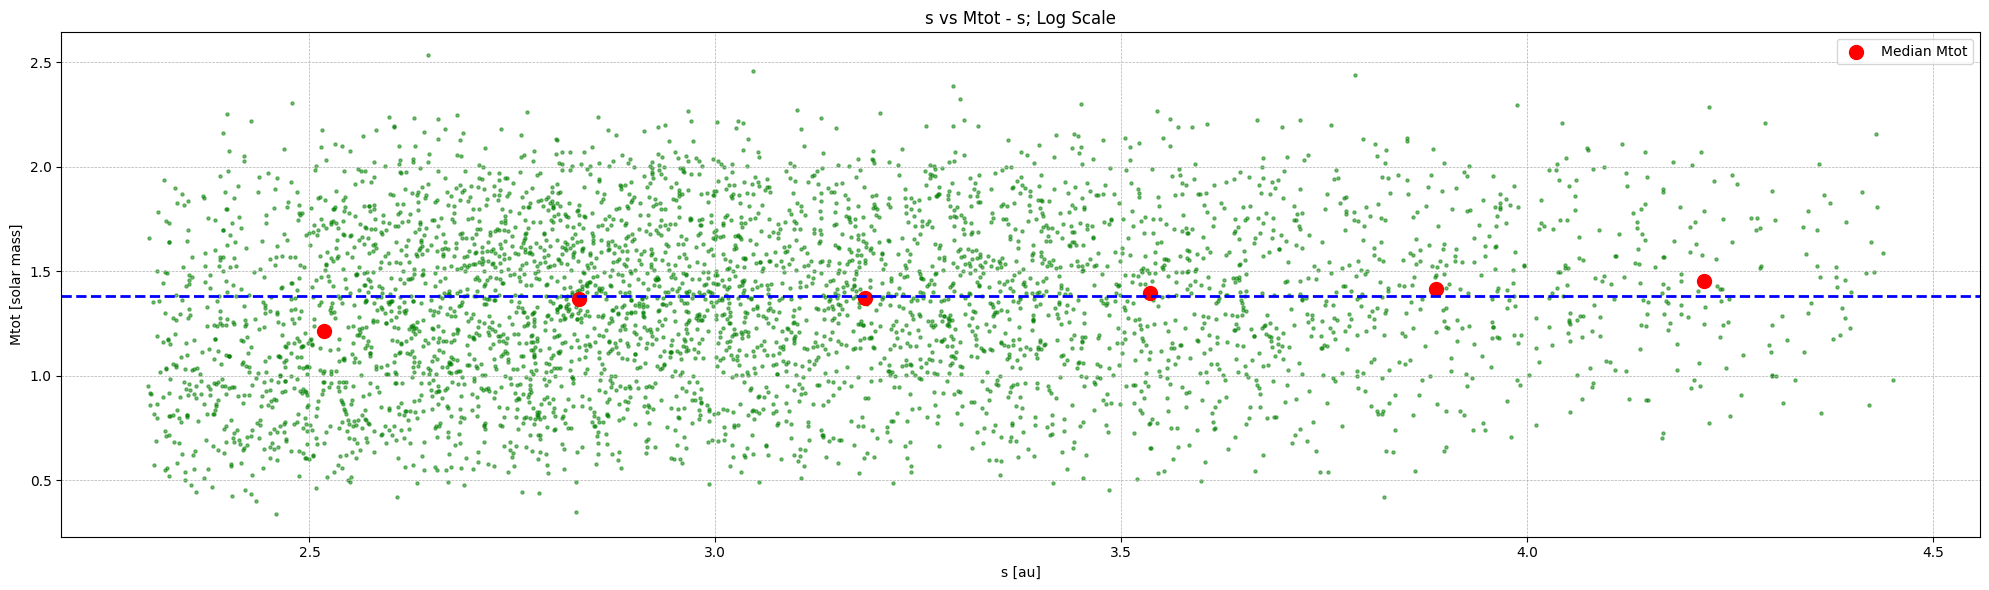

In [133]:
# 로그 변환
df['log_s'] = np.log10(df['s'])

# log_s 범위를 6등분
bins = np.linspace(df['log_s'].min(), df['log_s'].max(), 7)
df['s_bin'] = pd.cut(df['log_s'], bins, labels=False)

# 각 구간에서 log_s와 Mtot의 중간값 계산
mtot_medians = df.groupby('s_bin')[['log_s', 'Mtot']].median()

# 모든 Mtot 중간값들의 중간값 계산
median_of_medians = mtot_medians['Mtot'].median()

# 산점도 그리기
plt.figure(figsize=(20, 6))
plt.scatter(df['log_s'], df['Mtot'], s=5, alpha=0.5, c='green')
plt.scatter(mtot_medians['log_s'], mtot_medians['Mtot'], color='red', s=100, label='Median Mtot')

# 중간값의 중간값을 지나는 수평선 그리기 (dashed 스타일)
plt.axhline(y=median_of_medians, color='blue', linestyle='--', linewidth=2)

# 축 설정
plt.title('s vs Mtot - s; Log Scale')
plt.xlabel('s [au]')
plt.ylabel('Mtot [solar mass]')
plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [135]:
print(median_of_medians)

1.3820845144667624


(7) dashed선과 비교할 때 중간 값들이 일정한가? 이 중간 값들의 양상과 위 (2)에서 구한 붉은 선의 양상이 어떻게 다른가?

이곳에서 Mtot은 쌍성계의 총 질량을 나타내며, 단위는 태양 질량(Msun, solar mass)로 나타내고 있다.

 문제 (6)의 결과로 그려진 그래프는 총 질량(Mtot)과 로그스케일에서의 s 관계를 보여주며, 파란색 점선은 모든 중간값들의 중간값을 나타낸다.

 문제 (6)의 그래프를 보면, 중간값들은 파란 점선 주변에서 약간 차이를 보이기는 하지만, 전반적으로 어떠한 큰 경향성 없이 상대적 일정한 패턴을 보인다. 이는 쌍성계의 총 질량(Mtot)가 별 사이의 거리(s)와 큰 상관관계가 없음을 나타낸다고 할 수 있다.

그리고 이를 (2)의 그래프 붉은선과 비교하겠다. (2)의 붉은선은 로그 스케일에서, s와 vp 사이의 관계가 기울기 -0.4670513388352032로 음의 상관관계를 보여주고 있다. 하지만, 문제 (6) 그래표의 총 질량(Mtot)는 로그 스케일의 s에 대해 크게 변하지 않고, 대체로 일정하다.

이러한 차이는 케플러의 제3법칙(v² ∝ M/r)으로 설명할 수 있는데, 총 질량(M)이 거리(r)에 관계없이 대체로 일정하기 때문에, 속도(v)와 거리(r) 사이에는 v ∝ r^(-0.5)의 관계가 성립한다. 고로 결론을 내리자면, 질량이 거리에 따라 크게 변하지 않기 때문에 s와 vp 사이에서 케플러 법칙에 따른 관계를 파악할 수 있다.